In [240]:
import seaborn as sns
import numpy as np
import sctop as top
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

Possible directions

What's the minimum amount of information we need to include in our model to capture the correct changes in proportion as a result of change in signaling?

Do we need to have some kind of threshold response, to measure "none, low, high" levels of signaling?

Do we need combinatorial signaling?

Can we find some structure in the matrices (vs. purely random matrices)? Some latent space of signaling?

# Data

[A map of signaling responses in the human airway epithelium](https://www.sciencedirect.com/science/article/pii/S2405471224000590)

Control + 17 conditions [GSE246368](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246368)

"Human bronchial epithelial cells were cultured at air-liquid interface (ALI) without treatment to drive differentiation into a pseudo- stratified epithelium that recapitulates the physiological cell types of the airway. The differentiated luminal cells were then stripped through calcium depletion, leaving the remaining basal cells to regenerate the tissue. This was done in the presence of a signaling agonist added to each well at a dosage 10- to 100-fold greater than the IC50. One condition was kept unperturbed for control."


Control + OSM + Ifng [GSE246441](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246441)

In [2]:
osm_ifng = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246441_all_10x_data.h5ad')
many_conditions = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246368_all_data.h5ad')

In [6]:
cellchatdb = pd.read_csv('/Users/maria/github/phenotype-signaling/cellchatdb.human.csv', index_col=0)

In [8]:
cellchatdb.head()

,interaction.interaction_name,interaction.pathway_name,interaction.ligand,interaction.receptor,interaction.agonist,interaction.antagonist,interaction.co_A_receptor,interaction.co_I_receptor,interaction.evidence,interaction.annotation,interaction.interaction_name_2
TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB1 - (TGFBR1+TGFBR2)
TGFB2_TGFBR1_TGFBR2,TGFB2_TGFBR1_TGFBR2,TGFb,TGFB2,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB2 - (TGFBR1+TGFBR2)
TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,TGFB3,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB3 - (TGFBR1+TGFBR2)
TGFB1_ACVR1B_TGFBR2,TGFB1_ACVR1B_TGFBR2,TGFb,TGFB1,ACVR1B_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,PMID: 27449815,Secreted Signaling,TGFB1 - (ACVR1B+TGFBR2)
TGFB1_ACVR1C_TGFBR2,TGFB1_ACVR1C_TGFBR2,TGFb,TGFB1,ACVR1C_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,PMID: 27449815,Secreted Signaling,TGFB1 - (ACVR1C+TGFBR2)


In [9]:
many_conditions.obs[['condition']].value_counts()

condition
None         7564
IGF1         6498
TGFB1        6265
TNFA         5863
ActA         4819
IFNA         4774
IL17A        4485
FGF10        4430
Adipo        4260
EGF          4127
BMP4         3891
IL13         3590
Leptin       3397
HGF          3396
OSM          2669
CHIR         2643
FGF2         2623
IFNG         2274
Name: count, dtype: int64

In [10]:
many_conditions.obs[many_conditions.obs['condition'] == 'None']['cell_states'].value_counts()

cell_states
Basal            2638
Club             2472
Multiciliated    2297
Ionocyte           67
Goblet             40
Tuft               40
PNEC               10
Indeterminate       0
Name: count, dtype: int64

# Phenotype-signal model with consumer-resource-like behavior

$$
\frac{dN_\mu}{dt} = \sum_{\nu \alpha} T_{\mu \nu} c_{\nu \alpha} L_{\alpha} N_{\nu} - \sum_{\gamma \beta} T_{\gamma \mu} c_{\mu \beta} L_{\beta} N_{\mu} - m_{\mu} N_{\mu}
$$

$$
\frac{dL_{\alpha}}{dt} = k_{\alpha} - r L_{\alpha} - \sum_{\mu \nu} T_{\mu \nu} c_{\nu \alpha} N_{\mu} L_{\alpha} + \sum_{\gamma} P_{\beta \gamma } N_{\gamma} 
$$

Variables:
- $N_{\mu}$: number of cells of cell type $\mu$
- $L_{\alpha}$: number of ligands of type $\alpha$
- $T_{\mu \nu}$: probability of transitioning from cell type $\nu$ to cell type $\mu$
- $c_{\nu \alpha}$: responsivity of cell type $\nu$ to ligand $\alpha$
- $m_{\mu}$: "mortality" of cell type $\mu$ (cell turnover rate for a given cell type?)
- $k_{\alpha}$: external supply of ligand $\alpha$
- $r$: dissociation rate of ligands
- $P_{\gamma \beta}$: production of ligand $\beta$ by cell type $\gamma$

Parameters from gene expression:
- Use Hopfield-like proximity-based likelihood for cell-type transition matrix: $T_{\mu \nu} = \frac{e^{- \beta ||\xi_{\mu} - \xi_{\nu}||^2}}{\sum_{\gamma} e^{- \beta ||\xi_{\mu} - \xi_{\gamma}||^2}}$ where $\xi_{\mu}$ is the gene expression profile for cell type $\mu$
- Combine receptor availibility with information about ligand-binding to find the phenotype-specific ligand responsivity: $c_{\nu \alpha} = \sum_i^{N_r} \xi_{\nu i} B_{i \alpha}$ where $i$ is summing over the receptors and $B$ is a binary matrix indicating whether ligand $\alpha$ binds to receptor $i$ (can use CellChat to sum over interacting ligand-receptor pairs)
- Use gene expression of ligand $\beta$ in cell type $\gamma$ for $P_{\gamma \beta}$

Free parameters: $m_{\mu}$, $d$

# 1. Processing the data

- Find average gene expression profiles for basal, club, ciliated, and goblet with sctop.process(..., average=True)
- Extract parameters for the model using CellChatDB and the average gene expression profiles

In [11]:
phenotypes = ['Basal', 'Club', 'Multiciliated'] # take the 3 most abundant types to start
control_data = many_conditions[many_conditions.obs['condition'] == 'None'] # take control condition (no signals added)
df_list = []

for ptype in phenotypes: 
    type_mask = control_data.obs['cell_states'] == ptype
    indices = control_data.obs[type_mask].index
    processed_counts = top.process(control_data[indices].X.T.toarray(), average=True)
    processed_counts.index = control_data.var.index
    processed_counts.columns = [ptype]
    df_list += [processed_counts]

control_xi = pd.concat(df_list, axis=1)

In [12]:
from itertools import combinations

# Add retinoic acid receptors
retinoic_receptors = ['RARA', 'RARB' 'RARG']

# Add genes encoding enzymes for producing retinoic acid 
retinoic_production = ['ALDH1A1', 'ALDH1A2', 'ALDH1A3']

# Update CellChatDB to include retinoic acid
signaldb = cellchatdb.copy()

RA_rows = []

for producer in retinoic_production:
    for receptor in retinoic_receptors:
        new_row = {'interaction.interaction_name': f'{producer}_{receptor}',
                'interaction.pathway_name': 'RA',
                'interaction.ligand': producer,
                'interaction.receptor': receptor
                }
        
        RA_rows += [pd.DataFrame(new_row, index=[f'{producer}_{receptor}'])]

signaldb = pd.concat([signaldb, pd.concat(RA_rows)])

In [13]:
genes = control_xi.index

ligands = np.intersect1d(genes, signaldb['interaction.ligand'])
receptors = np.intersect1d(genes, signaldb['interaction.receptor'])

print(f'Data includes {len(ligands)} ligands and {len(receptors)} receptors')
print(f'(Out of {len(signaldb['interaction.ligand'].unique())} possible ligands and {len(signaldb['interaction.receptor'].unique())} possible receptors in the CellChat database)')

Data includes 532 ligands and 359 receptors
(Out of 549 possible ligands and 509 possible receptors in the CellChat database)


In [14]:
# Binary receptor x ligand interaction matrix from CellChatDB
lr_pairs = (
    signaldb[['interaction.receptor', 'interaction.ligand']]
)

receptor_ligand_matrix = pd.crosstab(
    lr_pairs['interaction.receptor'],
    lr_pairs['interaction.ligand']
).astype(int)

receptor_ligand_matrix = receptor_ligand_matrix.loc[receptors, ligands]

In [15]:
# Use a version of the gene expression profiles where negative (lowly-expressed) genes
# are converted to 0's (to avoid adding negative terms to the dynamics)
# i.e.: lowly-expressed receptors/ligands have no effect
control_xi_nonneg = control_xi.clip(lower=0)

ligand_responsivity = control_xi_nonneg.loc[receptors].T.dot(receptor_ligand_matrix)
ligand_production = control_xi_nonneg.loc[ligands]

In [264]:
ligand_responsivity

interaction.ligand,ADCYAP1,ADGRE5,ADIPOQ,ADM,AGRN,AGT,ALCAM,AMH,ANGPT1,ANGPT2,...,WNT5B,WNT6,WNT7A,WNT7B,WNT8A,WNT8B,WNT9A,WNT9B,XCL1,XCL2
Basal,0.0,0.005754,0.019619,0.004267,0.009432,0.003170,0.002371,0.0,0.000000,0.000000,...,0.048147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000697,0.000697
Club,0.0,0.010863,0.019356,0.003683,0.009217,0.002602,0.001431,0.0,0.000601,0.000601,...,0.043360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000601,0.000601
Multiciliated,0.0,0.007829,0.018909,0.003629,0.008848,0.004206,0.001955,0.0,0.000491,0.000491,...,0.039999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [18]:
from scipy.special import softmax

beta = 5 # fairly low to allow for transitions

# Gene expression profiles: shape (n_genes, n_phenotypes)
xi = control_xi[phenotypes].values

# Squared Euclidean distances between phenotype profiles
# D[mu, nu] = ||xi_mu - xi_nu||^2
xi_T = xi.T  # (n_phenotypes, n_genes)
D = np.sum((xi_T[:, np.newaxis, :] - xi_T[np.newaxis, :, :])**2, axis=-1)

# T[mu, nu] = exp(-beta * D[mu, nu]) / sum_gamma exp(-beta * D[mu, gamma])
# softmax over columns (axis=1) for each row mu
cell_type_transitions = pd.DataFrame(
    softmax(-beta * D, axis=1),
    index=phenotypes,
    columns=phenotypes
)
cell_type_transitions


,Basal,Club,Multiciliated
Basal,0.555875,0.256935,0.187190
Club,0.250444,0.541831,0.207724
Multiciliated,0.195770,0.222876,0.581354


# Cell type transition tensors

Ligand-specific transition tensor, same softmax form as $T_{\mu\nu}$ but with an added term for the production or responsivity difference:

$$T^\alpha_{\mu\nu} = \frac{e^{-\beta \|\xi_\mu - \xi_\nu\|^2 + \gamma \, \Delta^\alpha_{\mu\nu}}}{\sum_{\nu'} e^{-\beta \|\xi_\mu - \xi_{\nu'}\|^2 + \gamma \, \Delta^\alpha_{\mu\nu'}}}$$

where $\Delta^\alpha_{\mu\nu}$ is the scaled squared difference (production or responsivity) for ligand $\alpha$ between cell types $\mu$ and $\nu$:

$$\Delta^{\alpha, \mathrm{prod}}_{\mu\nu} = (s\, P_{\alpha\mu} - s\, P_{\alpha\nu})^2, \qquad \Delta^{\alpha, \mathrm{resp}}_{\mu\nu} = (s\, c_{\mu\alpha} - s\, c_{\nu\alpha})^2$$

The scale factor $s = n_\text{genes} / n_\text{ligands}$ corrects for the dimensionality mismatch between $\|\xi_\mu - \xi_\nu\|^2$ (which sums over $\sim n_\text{genes}$ dimensions) and the ligand differences (which involve a single dimension per ligand $\alpha$), putting both terms on a comparable magnitude.

- $\gamma = 0$: recovers the ligand-independent base matrix $T_{\mu\nu}$
- $\gamma > 0$: increases transition probability toward cell types that differ more in production/responsivity for ligand $\alpha$


In [259]:
# Ligand-specific cell type transition tensors
# T_prod[alpha, mu, nu] and T_resp[alpha, mu, nu]: shape (n_ligands, n_phenotypes, n_phenotypes)
#
# Same softmax form as the base T, with an added squared-difference term:
#   T[alpha, mu, nu] = softmax(-beta * D + gamma * diff_sq[alpha], axis=1)[mu, nu]

P_arr = ligand_production.values    # (n_ligands, n_phenotypes)
C_arr = ligand_responsivity.values  # (n_phenotypes, n_ligands)
T_base = cell_type_transitions.values  # (n_phenotypes, n_phenotypes)

gamma = 1.0

# Production squared difference: (P[alpha, mu] - P[alpha, nu])^2
prod_diff_norm = (P_arr[:, :, np.newaxis] - P_arr[:, np.newaxis, :])**2  # (n_ligands, n_phenotypes, n_phenotypes)

# Responsivity squared difference: (C[mu, alpha] - C[nu, alpha])^2
C_T = C_arr.T  # (n_ligands, n_phenotypes)
resp_diff_norm = (C_T[:, :, np.newaxis] - C_T[:, np.newaxis, :])**2  # (n_ligands, n_phenotypes, n_phenotypes)

# Base logits: -beta * D, broadcast over ligands
beta = 0
base_logits = -beta * D[np.newaxis, :, :]  # (1, n_phenotypes, n_phenotypes)

T_prod = softmax(base_logits + gamma * prod_diff_norm, axis=2)
T_resp = softmax(base_logits + gamma * resp_diff_norm, axis=2)

print(f'T_prod shape: {T_prod.shape}  (n_ligands x n_phenotypes x n_phenotypes)')
print(f'T_resp shape: {T_resp.shape}')
print(f'Row sums check (T_prod[0]): {T_prod[0].sum(axis=1)}')  # should all be 1.0


T_prod shape: (532, 3, 3)  (n_ligands x n_phenotypes x n_phenotypes)
T_resp shape: (532, 3, 3)
Row sums check (T_prod[0]): [1. 1. 1.]


# 2. Simulations

In [19]:
from scipy.integrate import solve_ivp

# Parameters
m = 0.001  # mortality/turnover rate (equal for all phenotypes)
r = 0.01  # ligand dissociation rate

n_phenotypes = len(phenotypes)
n_ligands = len(ligands)

C = ligand_responsivity.values    # (n_phenotypes, n_ligands): c[nu, alpha]
T = cell_type_transitions.values  # (n_phenotypes, n_phenotypes): T[mu, nu]
P = ligand_production.values      # (n_ligands, n_phenotypes): P[alpha, gamma]
TC = T @ C                        # precompute (n_phenotypes, n_ligands)

rng = np.random.default_rng(seed=42)
k = rng.binomial(1, 0.1, size=n_ligands) # fixed random external supply rate per ligand

def dydt(t, y):
    N = y[:n_phenotypes]
    L = y[n_phenotypes:]

    CL = C @ L  # effective signal per phenotype, shape (n_phenotypes,)

    # dN_mu/dt = sum_{nu,alpha} T_{mu,nu} c_{nu,alpha} L_alpha N_nu
    #           - sum_{gamma,beta} T_{gamma,mu} c_{mu,beta} L_beta N_mu
    #           - m * N_mu
    gain_N = T @ (N * CL)
    loss_N = N * CL * T.sum(axis=0)
    dN = gain_N - loss_N - m * N

    # dL_alpha/dt = k_alpha - r L_alpha
    #              - L_alpha * sum_{mu,nu} T_{mu,nu} c_{nu,alpha} N_mu
    #              + sum_gamma P_{gamma,alpha} N_gamma
    consumption_L = L * (TC.T @ N)
    production_L = P @ N
    dL = k - r * L - consumption_L + production_L

    return np.concatenate([dN, dL])

# Initial conditions: only basal cells, no ligands
N0 = np.array([1, 0, 0])
L0 = np.zeros(n_ligands)
y0 = np.concatenate([N0, L0])

t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
print(f'Integration {"succeeded" if sol.success else "failed"}: {sol.message}')


Integration succeeded: The solver successfully reached the end of the integration interval.


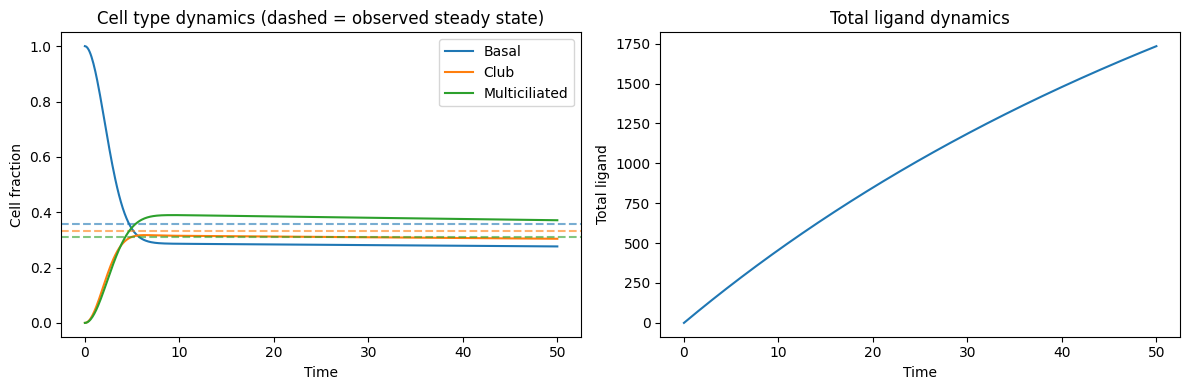

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed steady-state fractions from control data (normalized to phenotypes of interest)
observed_counts = control_data.obs['cell_states'].value_counts()
observed_counts = observed_counts[phenotypes]
observed_fractions = observed_counts / observed_counts.sum()

N_sol = sol.y[:n_phenotypes]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, ptype in enumerate(phenotypes):
    axes[0].plot(sol.t, N_sol[i], label=ptype, color=colors[i])
    axes[0].axhline(observed_fractions[ptype], color=colors[i], linestyle='--', alpha=0.6)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cell fraction')
axes[0].set_title('Cell type dynamics (dashed = observed steady state)')
axes[0].legend()

L_sol = sol.y[n_phenotypes:]
axes[1].plot(sol.t, L_sol.sum(axis=0))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total ligand')
axes[1].set_title('Total ligand dynamics')

plt.tight_layout()
plt.show()


Add [basal medium](https://bioscience.lonza.com/lonza_bs/CH/en/Primary-and-Stem-Cells/p/000000000000185308/BEGM-Bronchial-Epithelial-Cell-Growth-Medium-BulletKit)

	1 x Orange Cap Vial with BPE, 2.00 mL
	1 x Lilac Cap Vial with Insulin, 0.50 mL
	1 x Natural Cap Vial with Hydrocortisone, 0.50 mL
	1 x Red Cap Vial with GA-1000, 0.50 mL
	1 x Amber Vial with Retinoic Acid, 0.50 mL
	1 x Natural Cap Vial with Transferrin, 0.50 mL
	1 x Amber Vial with Triiodothyronine, 0.50 mL
	1 x Amber Vial with Epinephrine, 0.50 mL
	1 x Green Cap Vial with hEGF, 0.50 mL


| Ingredient | Mapping to pathways/receptors/ligands |
| -------- | -------- |
| Bovine Pituitary Extract, 2.00 mL |  Most similar: FGF, EGF, IGF/PDGF |
| Insulin, 0.50 mL | INS/IGF |
| Retinoic Acid, 0.50 mL | Nuclear receptor: RAR (not in CellChat)|
| hEGF, 0.50 mL | EGF |

In [21]:
medium_pathways = ['FGF', 'EGF', 'IGF', 'PDGF', 'INS', 'IGF']
medium_pathways_cellchat = np.array([])

# Find the actual names used in cellchat
for pathway in medium_pathways:
    find_in_cellchat = np.unique([name for name in signaldb['interaction.pathway_name'] if pathway in name])
    medium_pathways_cellchat = np.append(medium_pathways_cellchat, find_in_cellchat)

medium_pathways_cellchat = np.unique(medium_pathways_cellchat)
print(medium_pathways_cellchat)

# remove 'VEGF'
medium_pathways_cellchat = ['EGF', 'FGF', 'IGF', 'INSULIN', 'PDGF', 'RA']
print(medium_pathways_cellchat)

['EGF' 'FGF' 'IGF' 'INSULIN' 'PDGF' 'VEGF']
['EGF', 'FGF', 'IGF', 'INSULIN', 'PDGF', 'RA']


In [22]:
medium_ligands = np.array([])

for pathway in medium_pathways_cellchat:
    these_ligands = signaldb[signaldb['interaction.pathway_name'] == pathway]['interaction.ligand']
    medium_ligands = np.append(medium_ligands, these_ligands)

medium_ligands = np.unique(medium_ligands)
print(medium_ligands)

['ALDH1A1' 'ALDH1A2' 'ALDH1A3' 'AREG' 'BTC' 'EGF' 'EREG' 'FGF1' 'FGF10'
 'FGF16' 'FGF17' 'FGF18' 'FGF19' 'FGF2' 'FGF20' 'FGF21' 'FGF22' 'FGF23'
 'FGF3' 'FGF4' 'FGF5' 'FGF6' 'FGF7' 'FGF8' 'FGF9' 'HBEGF' 'IGF1' 'IGF2'
 'IGFL3' 'INS' 'PDGFA' 'PDGFB' 'PDGFC' 'PDGFD' 'TGFA']


In [23]:
supplied_ligands = pd.DataFrame(np.zeros(len(ligands)), index=ligands)

for ligand in medium_ligands:
    supplied_ligands.loc[ligand] = 1

Integration succeeded: The solver successfully reached the end of the integration interval.


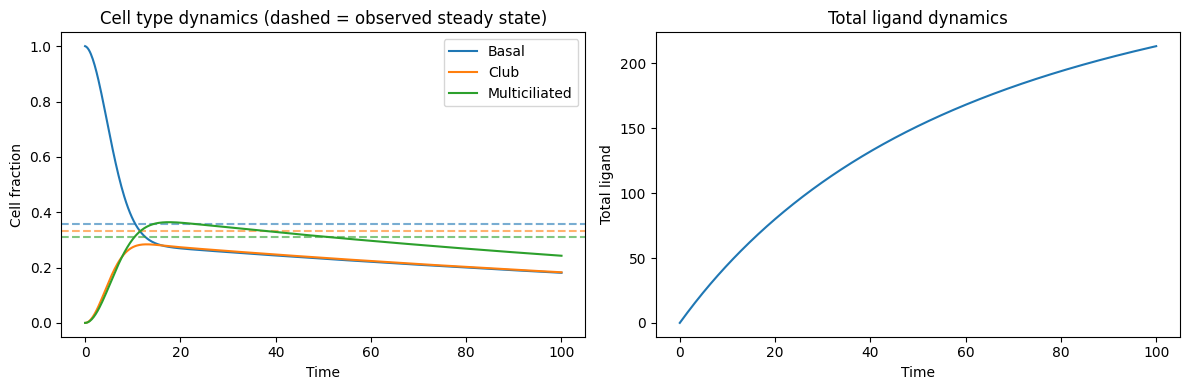

In [28]:
from scipy.integrate import solve_ivp

# Parameters
m = 0.005  # mortality/turnover rate (equal for all phenotypes)
r = 0.01  # ligand dissociation rate

n_phenotypes = len(phenotypes)
n_ligands = len(ligands)

C = ligand_responsivity.values    # (n_phenotypes, n_ligands): c[nu, alpha]
T = cell_type_transitions.values  # (n_phenotypes, n_phenotypes): T[mu, nu]
P = ligand_production.values      # (n_ligands, n_phenotypes): P[alpha, gamma]
TC = T @ C                        # precompute (n_phenotypes, n_ligands)

rng = np.random.default_rng(seed=42)
# k = rng.binomial(1, 0.1, size=n_ligands)  # fixed random external supply rate per ligand
k = supplied_ligands[0]*0.1

def dydt(t, y):
    N = y[:n_phenotypes]
    L = y[n_phenotypes:]

    CL = C @ L  # effective signal per phenotype, shape (n_phenotypes,)

    # dN_mu/dt = sum_{nu,alpha} T_{mu,nu} c_{nu,alpha} L_alpha N_nu
    #           - sum_{gamma,beta} T_{gamma,mu} c_{mu,beta} L_beta N_mu
    #           - m * N_mu
    gain_N = T @ (N * CL)
    loss_N = N * CL * T.sum(axis=0)
    dN = gain_N - loss_N - m * N

    # dL_alpha/dt = k_alpha - r L_alpha
    #              - L_alpha * sum_{mu,nu} T_{mu,nu} c_{nu,alpha} N_mu
    #              + sum_gamma P_{gamma,alpha} N_gamma
    consumption_L = L * (TC.T @ N)
    production_L = P @ N
    dL = k - r * L - consumption_L + production_L

    return np.concatenate([dN, dL])

# Initial conditions: only basal cells, no ligands
N0 = np.array([1, 0, 0])
L0 = np.zeros(n_ligands)
y0 = np.concatenate([N0, L0])

t_span = (0, 100)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
print(f'Integration {"succeeded" if sol.success else "failed"}: {sol.message}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed steady-state fractions from control data (normalized to phenotypes of interest)
observed_counts = control_data.obs['cell_states'].value_counts()
observed_counts = observed_counts[phenotypes]
observed_fractions = observed_counts / observed_counts.sum()

N_sol = sol.y[:n_phenotypes]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, ptype in enumerate(phenotypes):
    axes[0].plot(sol.t, N_sol[i], label=ptype, color=colors[i])
    axes[0].axhline(observed_fractions[ptype], color=colors[i], linestyle='--', alpha=0.6)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cell fraction')
axes[0].set_title('Cell type dynamics (dashed = observed steady state)')
axes[0].legend()

L_sol = sol.y[n_phenotypes:]
axes[1].plot(sol.t, L_sol.sum(axis=0))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total ligand')
axes[1].set_title('Total ligand dynamics')

plt.tight_layout()
plt.show()


Integration succeeded: The solver successfully reached the end of the integration interval.


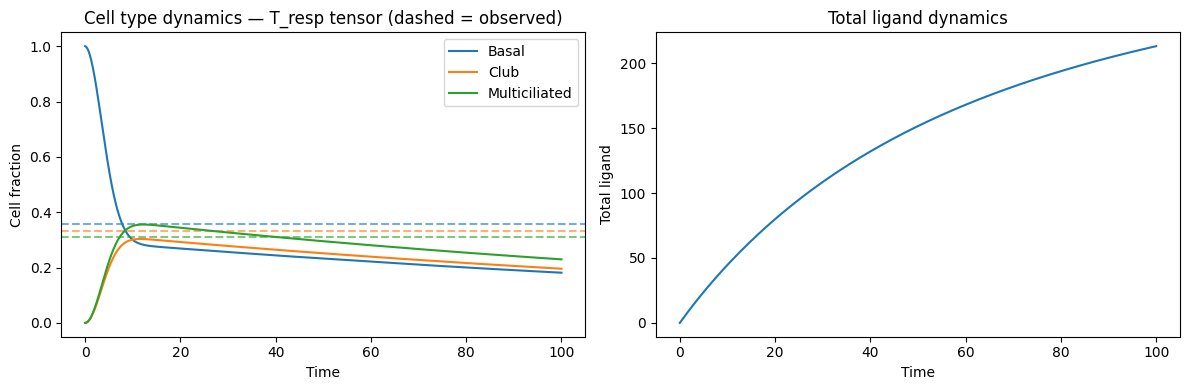

In [38]:
from scipy.integrate import solve_ivp

# Parameters
m = 0.005
r = 0.01

n_phenotypes = len(phenotypes)
n_ligands = len(ligands)

C = ligand_responsivity.values  # (n_phenotypes, n_ligands)
P = ligand_production.values    # (n_ligands, n_phenotypes)

# Select tensor: T_resp (responsivity-based) or T_prod (production-based)
T_alpha = T_prod  # shape: (n_ligands, n_phenotypes, n_phenotypes)

# Precompute outside ODE:
# col_sum[alpha, nu] = sum_mu T_alpha[alpha, mu, nu]  — used in loss term
T_alpha_col_sum = T_alpha.sum(axis=1)           # (n_ligands, n_phenotypes)
# TC_alpha[mu, alpha] = sum_nu T_alpha[alpha, mu, nu] * C[nu, alpha]  — used in ligand consumption
TC_alpha = np.einsum('amn,na->ma', T_alpha, C)  # (n_phenotypes, n_ligands)

k = supplied_ligands[0] * 0.1

def dydt_tensor(t, y):
    N = y[:n_phenotypes]
    L = y[n_phenotypes:]

    CL_w = C * L  # (n_phenotypes, n_ligands): C[nu, alpha] * L[alpha]

    # gain_N[mu] = sum_{nu, alpha} T_alpha[alpha, mu, nu] * C[nu, alpha] * L[alpha] * N[nu]
    gain_N = np.einsum('amn,na,n->m', T_alpha, CL_w, N)

    # loss_N[mu] = N[mu] * sum_{gamma, alpha} T_alpha[alpha, gamma, mu] * C[mu, alpha] * L[alpha]
    loss_N = N * np.einsum('ma,am->m', CL_w, T_alpha_col_sum)

    dN = gain_N - loss_N - m * N

    # consumption_L[alpha] = L[alpha] * sum_mu TC_alpha[mu, alpha] * N[mu]
    consumption_L = L * (TC_alpha.T @ N)
    production_L = P @ N
    dL = k - r * L - consumption_L + production_L

    return np.concatenate([dN, dL])

N0 = np.array([1, 0, 0])
L0 = np.zeros(n_ligands)
y0 = np.concatenate([N0, L0])

t_span = (0, 100)
t_eval = np.linspace(*t_span, 500)

sol_tensor = solve_ivp(dydt_tensor, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
print(f'Integration {"succeeded" if sol_tensor.success else "failed"}: {sol_tensor.message}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

observed_counts = control_data.obs['cell_states'].value_counts()[phenotypes]
observed_fractions = observed_counts / observed_counts.sum()

N_sol = sol_tensor.y[:n_phenotypes]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, ptype in enumerate(phenotypes):
    axes[0].plot(sol_tensor.t, N_sol[i], label=ptype, color=colors[i])
    axes[0].axhline(observed_fractions[ptype], color=colors[i], linestyle='--', alpha=0.6)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cell fraction')
axes[0].set_title('Cell type dynamics — T_resp tensor (dashed = observed)')
axes[0].legend()

L_sol = sol_tensor.y[n_phenotypes:]
axes[1].plot(sol_tensor.t, L_sol.sum(axis=0))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total ligand')
axes[1].set_title('Total ligand dynamics')

plt.tight_layout()
plt.show()


In [ ]:
print(control_data.obs['cell_states'].value_counts())


Conditions: ['IL17A', 'FGF10', 'IL13', 'IFNA', 'HGF', ..., 'TGFB1', 'IGF1', 'IFNG', 'Leptin', 'FGF2']
Length: 18
Categories (18, object): ['ActA', 'Adipo', 'BMP4', 'CHIR', ..., 'None', 'OSM', 'TGFB1', 'TNFA']

FGF2 in ligands: True
BMP4 in ligands: True
FGF2 in signaldb ligands: True
BMP4 in signaldb ligands: True


# 3. Multi-condition simulations with extended phenotypes

Simulate 3 conditions (medium only, medium + FGF2, medium + BMP4) using 6 cell types:
Basal, Club, Multiciliated, Ionocyte, Goblet, Tuft.


In [357]:
# ── Extended phenotype set ──────────────────────────────────────────────────
phenotypes_ext = ['Basal', 'Club', 'Multiciliated', 'Ionocyte', 'Goblet', 'Tuft']

df_list_ext = []
for ptype in phenotypes_ext:
    type_mask = control_data.obs['cell_states'] == ptype
    indices = control_data.obs[type_mask].index
    pc = top.process(control_data[indices].X.T.toarray(), average=True)
    pc.index = control_data.var.index
    pc.columns = [ptype]
    df_list_ext.append(pc)

control_xi_ext = pd.concat(df_list_ext, axis=1)
control_xi_nonneg_ext = control_xi_ext.clip(lower=0)

ligand_responsivity_ext = control_xi_nonneg_ext.loc[receptors].T.dot(receptor_ligand_matrix)
ligand_production_ext   = control_xi_nonneg_ext.loc[ligands]

print(f'ligand_responsivity_ext: {ligand_responsivity_ext.shape}  (n_phenotypes x n_ligands)')
print(f'ligand_production_ext:   {ligand_production_ext.shape}  (n_ligands x n_phenotypes)')


ligand_responsivity_ext: (6, 532)  (n_phenotypes x n_ligands)
ligand_production_ext:   (532, 6)  (n_ligands x n_phenotypes)


In [530]:
ligand_responsivity_ext

interaction.ligand,ADCYAP1,ADGRE5,ADIPOQ,ADM,AGRN,AGT,ALCAM,ALDH1A1,ALDH1A2,ALDH1A3,...,WNT5B,WNT6,WNT7A,WNT7B,WNT8A,WNT8B,WNT9A,WNT9B,XCL1,XCL2
Basal,0.0,0.005754,0.019619,0.004267,0.009432,0.003170,0.002371,0.007590,0.007590,0.007590,...,0.048147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000697,0.000697
Club,0.0,0.010863,0.019356,0.003683,0.009217,0.002602,0.001431,0.007122,0.007122,0.007122,...,0.043360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000601,0.000601
Multiciliated,0.0,0.007829,0.018909,0.003629,0.008848,0.004206,0.001955,0.005694,0.005694,0.005694,...,0.039999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Ionocyte,0.0,0.005965,0.022721,0.005265,0.010037,0.004582,0.000000,0.007388,0.007388,0.007388,...,0.047036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Goblet,0.0,0.015381,0.022244,0.004928,0.010117,0.000000,0.000000,0.006092,0.006092,0.006092,...,0.047600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Tuft,0.0,0.005897,0.022388,0.000000,0.010457,0.000000,0.000000,0.006327,0.006327,0.006327,...,0.037063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [523]:
# ── Transition matrix and ligand-specific tensors for extended phenotypes ───
from scipy.special import softmax

# beta = 35: no-medium case matches well
# beta = 50: normal medium matches well

beta_base = 35.0
gamma_ext = -5.0

xi_ext   = control_xi_ext[phenotypes_ext].values
xi_T_ext = xi_ext.T  # (n_phenotypes, n_genes)
D_ext = np.sum((xi_T_ext[:, np.newaxis, :] - xi_T_ext[np.newaxis, :, :])**2, axis=-1)

cell_type_transitions_ext = pd.DataFrame(
    softmax(-beta_base * D_ext, axis=1),
    index=phenotypes_ext, columns=phenotypes_ext
)

# Scale by n_genes / n_ligands so differences are on the same scale as D_ext
# (D_ext sums over n_genes dimensions; ligand differences sum over 1 dimension)
n_genes_ext = xi_ext.shape[0]
n_ligands_ext = len(ligands)
scale = n_genes_ext / n_ligands_ext

# Ligand-specific tensors
P_arr_ext = ligand_production_ext.values * scale    # (n_ligands, n_phenotypes)
C_arr_ext = ligand_responsivity_ext.values * scale  # (n_phenotypes, n_ligands)

# Squared pairwise differences
prod_diff_norm_ext = (P_arr_ext[:, :, np.newaxis] - P_arr_ext[:, np.newaxis, :])**2  # (n_lig, n_ph, n_ph)
C_T_ext = C_arr_ext.T  # (n_ligands, n_phenotypes)
resp_diff_norm_ext = (C_T_ext[:, :, np.newaxis] - C_T_ext[:, np.newaxis, :])**2      # (n_lig, n_ph, n_ph)

# Base logits: -beta * D/D_max, broadcast over ligands
base_logits_ext = -beta_base * D_ext[np.newaxis, :, :]  # (1, n_ph, n_ph)
T_prod_ext = softmax(base_logits_ext + gamma_ext * prod_diff_norm_ext, axis=2)
T_resp_ext = softmax(base_logits_ext + gamma_ext * resp_diff_norm_ext, axis=2)

print(f'T_prod_ext shape: {T_prod_ext.shape}  (n_ligands x n_phenotypes x n_phenotypes)')
print(f'Row sums check (T_prod_ext[0]): {T_prod_ext[0].sum(axis=1)}')


T_prod_ext shape: (532, 6, 6)  (n_ligands x n_phenotypes x n_phenotypes)
Row sums check (T_prod_ext[0]): [1.0000001  0.9999999  1.0000001  1.         0.99999994 1.        ]


In [527]:
from scipy.integrate import solve_ivp

# ── ODE parameters ──────────────────────────────────────────────────────────
m_ext = 0.001
r_ext = 0.01

n_ph_ext  = len(phenotypes_ext)
n_lig_ext = len(ligands)

C_ext = ligand_responsivity_ext.values   # (n_ph, n_lig)
P_ext = ligand_production_ext.values     # (n_lig, n_ph)

# Choose which cell-type transition matrix to use: 
# T_resp_ext, based on ligand responsivity
# T_prod_ext, based on ligand productivity
T_alpha_ext         = T_prod_ext                              # (n_lig, n_ph, n_ph)
T_alpha_col_sum_ext = T_alpha_ext.sum(axis=1)                 # (n_lig, n_ph)
TC_alpha_ext        = np.einsum('amn,na->ma', T_alpha_ext, C_ext)  # (n_ph, n_lig)

# ── External supply vectors ─────────────────────────────────────────────────
k_none   = supplied_ligands[0] * 0.0   # no external supply
k_medium = supplied_ligands[0] * 0.001   # medium ligands

# Medium + FGF2
k_fgf2 = k_medium.copy()
k_fgf2.loc['FGF2'] = 10

# Medium + BMP4
k_bmp4 = k_medium.copy()
k_bmp4.loc['BMP4'] = 10

# ── ODE factory ─────────────────────────────────────────────────────────────
def make_dydt_ext(k_vec):
    k = k_vec.values
    def dydt(t, y):
        N = y[:n_ph_ext]
        L = y[n_ph_ext:]
        CL_w = C_ext * L
        gain_N = np.einsum('amn,na,n->m', T_alpha_ext, CL_w, N)
        loss_N = N * np.einsum('ma,am->m', CL_w, T_alpha_col_sum_ext)
        dN = gain_N - loss_N - m_ext * N
        consumption_L = L * (TC_alpha_ext.T @ N)
        production_L = P_ext @ N
        dL = k - r_ext * L - consumption_L + production_L
        return np.concatenate([dN, dL])
    return dydt
# ── Run 4 simulations ───────────────────────────────────────────────────────
N0_ext = np.zeros(n_ph_ext); N0_ext[0] = 1.0   # start all-Basal
L0_ext = np.zeros(n_lig_ext)
y0_ext = np.concatenate([N0_ext, L0_ext])

t_span_ext = (0, 5000)
t_eval_ext = np.linspace(*t_span_ext, 1000)

conditions_k = {
    'No medium':     k_none,
    'Medium':        k_medium,
    'Medium + FGF2': k_fgf2,
    'Medium + BMP4': k_bmp4,
}

# Use Radau (implicit, stiff solver) with tighter tolerances to distinguish
# numerical noise from genuine oscillations.
solutions_ext = {}
for cond_name, k_vec in conditions_k.items():
    sol = solve_ivp(make_dydt_ext(k_vec), t_span_ext, y0_ext,
                    t_eval=t_eval_ext, method='Radau', rtol=1e-6, atol=1e-9)
    solutions_ext[cond_name] = sol
    print(f'{cond_name}: {"succeeded" if sol.success else "FAILED — " + sol.message}')



No medium: succeeded
Medium: succeeded
Medium + FGF2: succeeded
Medium + BMP4: succeeded


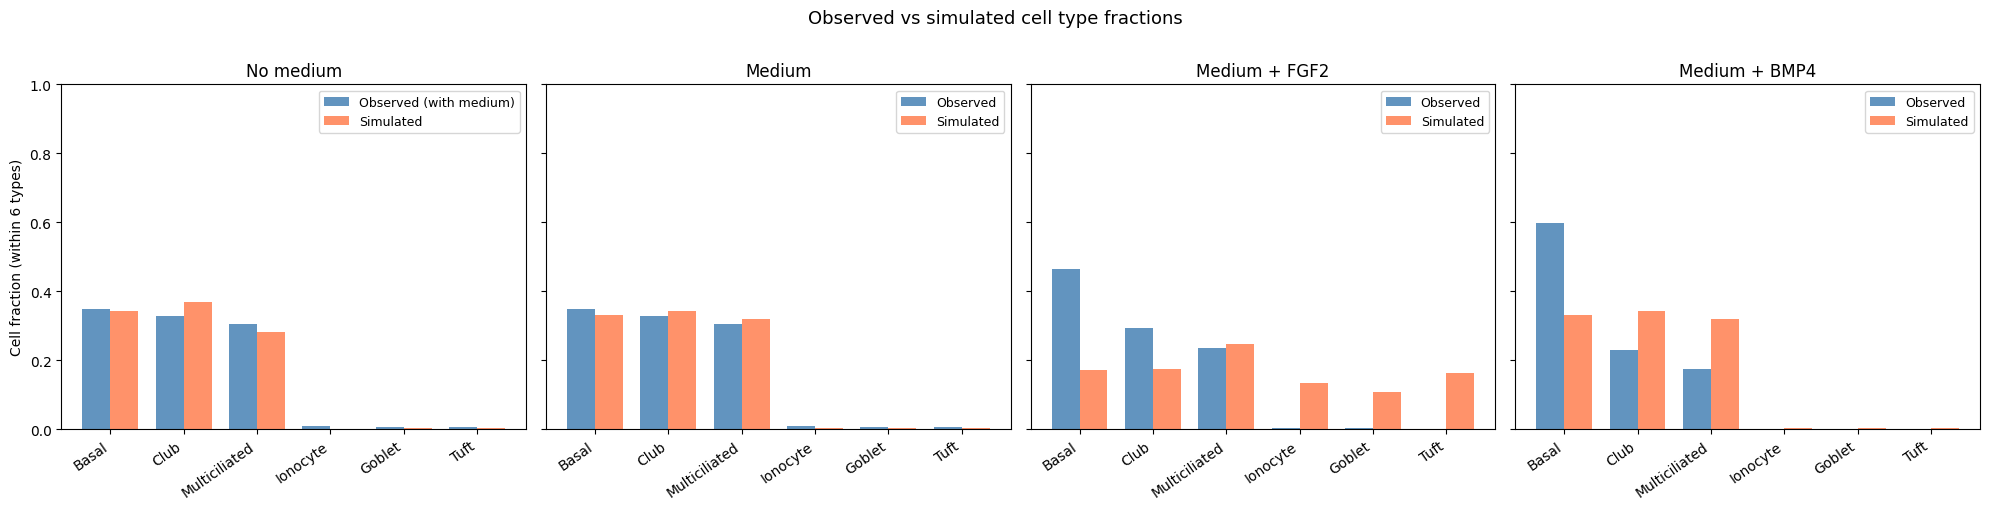

In [528]:
# ── Observed vs Simulated comparison ───────────────────────────────────────
# Map simulation condition names to dataset condition labels
data_condition_map = {
    'No medium':     'None',
    'Medium':        'None',
    'Medium + FGF2': 'FGF2',
    'Medium + BMP4': 'BMP4',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
x = np.arange(len(phenotypes_ext))
width = 0.38

for ax, (cond_name, data_cond) in zip(axes, data_condition_map.items()):
    # ── Observed fractions (normalized within the 6 phenotypes) ──
    cond_adata = many_conditions[many_conditions.obs['condition'] == data_cond]
    obs_counts = cond_adata.obs['cell_states'].value_counts().reindex(phenotypes_ext, fill_value=0)
    obs_fracs  = obs_counts / obs_counts.sum()

    # ── Simulated fractions (final time point, clipped non-negative) ──
    N_final   = solutions_ext[cond_name].y[:n_ph_ext, -1].clip(0)
    sim_fracs = N_final / N_final.sum() if N_final.sum() > 0 else N_final

    if cond_name == 'No medium':
        obs_label = 'Observed (with medium)'
    else:
        obs_label = 'Observed'

    bars_obs = ax.bar(x - width / 2, obs_fracs.values, width,
                      label=obs_label, color='steelblue', alpha=0.85)
    bars_sim = ax.bar(x + width / 2, sim_fracs,        width,
                      label='Simulated', color='coral',     alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(phenotypes_ext, rotation=35, ha='right', fontsize=10)
    ax.set_title(cond_name, fontsize=12)
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('Cell fraction (within 6 types)')
    ax.legend(fontsize=9)

plt.suptitle('Observed vs simulated cell type fractions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


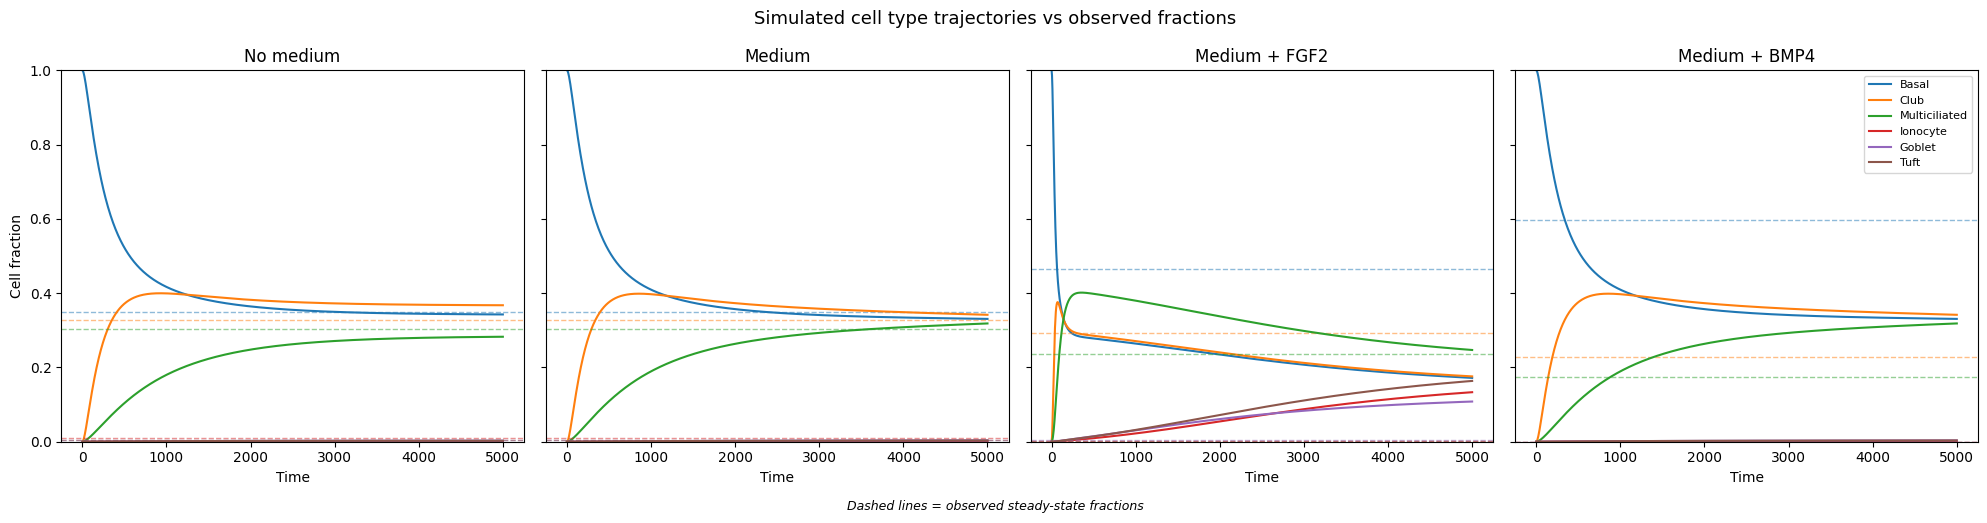

In [529]:
# ── Trajectory plots: simulated fractions over time, observed as dashed lines ──
data_condition_map = {
    'No medium':     'None',
    'Medium':        'None',
    'Medium + FGF2': 'FGF2',
    'Medium + BMP4': 'BMP4',
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (cond_name, data_cond) in zip(axes, data_condition_map.items()):
    sol = solutions_ext[cond_name]
    N_sol = sol.y[:n_ph_ext, :]                          # (n_ph, n_t)
    N_sol_clipped = N_sol.clip(0)
    total = N_sol_clipped.sum(axis=0)
    total = np.where(total > 0, total, 1.0)
    fracs = N_sol_clipped / total                        # normalised fractions

    # Observed fractions (dashed horizontal lines)
    cond_adata = many_conditions[many_conditions.obs['condition'] == data_cond]
    obs_counts = cond_adata.obs['cell_states'].value_counts().reindex(phenotypes_ext, fill_value=0)
    obs_fracs  = obs_counts / obs_counts.sum()

    for i, ptype in enumerate(phenotypes_ext):
        ax.plot(sol.t, fracs[i], color=colors[i], label=ptype)
        ax.axhline(obs_fracs[ptype], color=colors[i], linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Time')
    ax.set_title(cond_name, fontsize=12)
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('Cell fraction')
    if ax is axes[-1]:
        ax.legend(fontsize=8, loc='upper right')

# Shared legend note
fig.text(0.5, -0.02, 'Dashed lines = observed steady-state fractions',
         ha='center', fontsize=9, style='italic')
plt.suptitle('Simulated cell type trajectories vs observed fractions', fontsize=13)
plt.tight_layout()
plt.show()
